# 뷰티 스타일 AI 분석 — 파이썬 소스

**인공지능 소프트웨어 중간평가 · 오경민**

- 데모(웹, 설치 없이 실행): https://huggingface.co/spaces/kyoungminOh/beauty-style-ai
- 전체 소스(웹 앱 · 학습 스크립트): https://github.com/rudals906377/AI

웹 앱은 **Transformers.js** 로 같은 모델을 브라우저 안에서 실행합니다(사진이 서버로 가지 않음).
이 노트북은 그 핵심 과정을 **파이썬으로 그대로 옮긴 것**이고, 웹 앱과 같은 파일(라벨 사전 · 라벨 문장 임베딩 · 학습한 분류 헤드)을 씁니다.

| 절 | 내용 | 웹 앱의 해당 파일 |
|---|---|---|
| 1 | 준비 (패키지 · 파일 불러오기) | `index.html` |
| 2 | 비전 모델 (Marqo FashionSigLIP) | `encoders.js` |
| 3 | 라벨 사전 324개 · 라벨 문장 임베딩 · 학습 헤드 | `taxonomy.js` · `embeddings/` · `heads/` |
| 4 | 분석: 카테고리 판별 → 속성 32그룹 판단 (제로샷 + 학습 헤드 + 확률 보정) | `analyzer.js` |
| 5 | 한국어 설명 문장 (확신도에 따라 "~예요" / "~로 보여요" / 생략) | `describe.js` |
| 6 | 예시 사진 분석과 웹 앱 결과 비교 | — |
| 7 | 분류 헤드 학습 방법 (제로샷에서 출발하는 경량 분류기) | `tools/train-heads.py` |
| 8 | 내 얼굴 분석: 얼굴형 측정 · 가림 점검 · 얼굴형 확률 (MediaPipe) | `face.js` · `face-advice.js` |

**Colab 에서 실행**: 런타임 → 모두 실행. 처음 한 번 모델(약 800MB)을 내려받습니다. GPU 없이 CPU 로도 됩니다.

## 1. 준비

In [1]:
# Colab · 새 환경이면 패키지를 설치한다 (이미 있으면 건너뜀)
import importlib.util, subprocess, sys
need = [p for p, m in [("open_clip_torch", "open_clip"), ("mediapipe", "mediapipe")] if importlib.util.find_spec(m) is None]
if need:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)

import base64, json, logging, math, os, time, urllib.parse, urllib.request, warnings
os.environ.setdefault("GLOG_minloglevel", "2")          # MediaPipe(C++) 안내 메시지 줄이기
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("HF_HUB_VERBOSITY", "error")
warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import torch
import open_clip

pd.set_option("display.max_colwidth", 80)
np.set_printoptions(precision=4, suppress=True)

# 저장소 안에서 실행하면 그 파일을 쓰고, 아니면(Colab 등) GitHub 에서 내려받는다
REPO_RAW = "https://raw.githubusercontent.com/rudals906377/AI/main/"
ROOT = next((r for r in (".", "..") if os.path.exists(os.path.join(r, "taxonomy.js"))), None)
CACHE = "beauty_ai_files"

def fetch(path):
    """저장소 기준 경로 → 로컬 파일 경로 (없으면 내려받는다)"""
    if ROOT and os.path.exists(os.path.join(ROOT, path)):
        return os.path.join(ROOT, path)
    local = os.path.join(CACHE, path)
    if not os.path.exists(local):
        os.makedirs(os.path.dirname(local), exist_ok=True)
        urllib.request.urlretrieve(REPO_RAW + urllib.parse.quote(path), local)
    return local

# 그래프의 한글 글꼴 (나눔고딕, 실패하면 영어 글꼴 그대로)
try:
    font = os.path.join(CACHE, "NanumGothic-Regular.ttf")
    if not os.path.exists(font):
        os.makedirs(CACHE, exist_ok=True)
        urllib.request.urlretrieve("https://cdn.jsdelivr.net/gh/google/fonts@main/ofl/nanumgothic/NanumGothic-Regular.ttf", font)
    matplotlib.font_manager.fontManager.addfont(font)
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
except Exception as e:
    print("한글 글꼴을 불러오지 못했습니다:", e)

print("저장소 파일:", "로컬" if ROOT else "GitHub 에서 내려받음", "| torch", torch.__version__, "| open_clip", open_clip.__version__)

저장소 파일: 로컬 | torch 2.14.1+cpu | open_clip 3.3.0


## 2. 비전 모델 — Marqo FashionSigLIP

패션 사진 수백만 장으로 추가 학습한 SigLIP(ViT-B/16) 모델입니다. 사진과 문장을 같은 768차원 공간에 놓습니다.
모델 6종(CLIP · SigLIP · SigLIP2 · FashionSigLIP 등)을 같은 평가 사진으로 비교해 정확도와 크기(브라우저용 94MB)를 함께 보고 골랐습니다.
웹 앱은 같은 가중치를 ONNX(8비트)로 바꾼 것을 Transformers.js 로 실행합니다. 전처리도 같습니다(224×224, 평균 · 표준편차 0.5).

In [2]:
MODEL_ID = "Marqo/marqo-fashionSigLIP"
t0 = time.time()
model, _, preprocess = open_clip.create_model_and_transforms("hf-hub:" + MODEL_ID)
model.eval()
print(f"모델 준비 {time.time() - t0:.1f}초")
print(preprocess)

def embed_image(img: Image.Image) -> np.ndarray:
    """사진 1장 → 정규화된 768차원 특징값 (웹 앱의 vision.embed 와 같음)"""
    with torch.no_grad():
        x = preprocess(img.convert("RGB")).unsqueeze(0)
        v = model.encode_image(x, normalize=True)[0].float().numpy()
    return v / np.linalg.norm(v)

모델 준비 7.0초
Compose(
    Resize(size=(224, 224), interpolation=bicubic, max_size=None, antialias=True)
    MaybeConvertMode()
    MaybeToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


## 3. 라벨 사전 · 라벨 문장 임베딩 · 학습한 분류 헤드

- **라벨 사전** 324개: 한국 매거진 · 살롱 · 커뮤니티 용어 약 440개를 조사해 헤어 9 · 네일 8 · 메이크업 11 · 타투 5그룹으로 정리.
  라벨마다 한국어 이름, 영어 묘사 문장, 한 줄 정의가 있습니다.
- **라벨 문장 임베딩**: 라벨마다 영어 묘사를 여러 문장 틀에 넣어 텍스트 모델로 임베딩하고 평균 낸 것(미리 계산해 둠).
  사진 임베딩과의 코사인 유사도로 고르면 **제로샷 분류**입니다.
- **학습 헤드**: 라벨을 단 사진 2,197장으로 그룹마다 학습한 작은 분류기(7절)와, 표시 확률을 실제 적중률에 맞춘 **보정 온도**.

In [3]:
TAX = json.load(open(fetch("notebook/taxonomy.json"), encoding="utf-8"))
EMB = json.load(open(fetch("embeddings/marqo-fashionSigLIP.json")))
HEADS = json.load(open(fetch("heads/marqo-fashionSigLIP.json")))
assert TAX["hash"] == EMB["hash"] == HEADS["hash"], "라벨 사전 버전이 맞지 않습니다"
CATS = TAX["categories"]
CONF = TAX["confidence"]  # {'high': 0.9, 'mid': 0.5}

def f32(b64):
    return np.frombuffer(base64.b64decode(b64), dtype=np.float32)

# 라벨 문장 임베딩 풀기 (카테고리 판별 문장 → 그룹별 라벨 → '뷰티 아님' 문장 순서로 이어 붙여 저장돼 있다)
buf = f32(EMB["data"]).reshape(-1, EMB["dim"])
INDEX, k = {}, 0
for c in CATS:
    L = EMB["layout"][c]
    detect = buf[k:k + L["detect"]]; k += L["detect"]
    groups = {}
    for g in TAX["tax"][c]["groups"]:
        n = L["groups"][g["key"]]
        groups[g["key"]] = buf[k:k + n]; k += n
    INDEX[c] = {"detect": detect, "groups": groups}
INDEX["other"] = buf[k:k + EMB["layout"]["other"]]

# 학습 헤드: 그룹마다 W(라벨 수 × 768), b, 제로샷과 섞는 비율 alpha
HEAD = {key: {"W": f32(h["W"]).reshape(h["rows"], HEADS["dim"]), "b": np.array(h["b"], dtype=np.float64), "alpha": h.get("alpha", 1.0)}
        for key, h in HEADS["groups"].items()}
CALIB = HEADS.get("calib", {})

rows = []
for c in CATS:
    for g in TAX["tax"][c]["groups"]:
        key = f"{c}.{g['key']}"
        rows.append({"카테고리": TAX["tax"][c]["label"], "그룹": g["label"], "라벨 수": len(g["labels"]),
                     "학습 헤드": "있음" if key in HEAD else "-", "섞는 비율 α": HEAD.get(key, {}).get("alpha", ""),
                     "보정 온도": CALIB.get(key, ""), "라벨 예": ", ".join(l["ko"] for l in g["labels"][:4])})
df_groups = pd.DataFrame(rows)
print(f"라벨 {sum(df_groups['라벨 수'])}개 · 그룹 {len(df_groups)}개 · 학습 헤드 {len(HEAD)}개 (카테고리 · 뷰티 판별 포함)")
df_groups

라벨 324개 · 그룹 33개 · 학습 헤드 34개 (카테고리 · 뷰티 판별 포함)


,카테고리,그룹,라벨 수,학습 헤드,섞는 비율 α,보정 온도,라벨 예
0,헤어,기장,4,있음,1.0,0.6300,"숏컷, 단발, 중단발, 긴머리"
1,헤어,커트,24,있음,0.75,0.9548,"레이어드컷, 허쉬컷, 원랭스, 칼단발"
2,헤어,연출,11,있음,1.0,0.9117,"풀어내린 머리, 포니테일, 똥머리, 슬릭번"
3,헤어,펌·질감,9,있음,0.75,0.7236,"생머리, C컬펌, 바깥C컬, S컬펌"
4,헤어,앞머리,9,있음,1.0,0.6910,"앞머리 없음, 풀뱅, 처피뱅, 시스루뱅"
5,헤어,컬러,18,있음,1.0,0.8706,"흑발, 블루블랙, 초코브라운, 밀크브라운"
6,헤어,컬러 기법,7,있음,1.0,1.0473,"전체 염색, 브릿지, 하이라이트, 발레아쥬"
7,헤어,톤,3,있음,1.0,0.6300,"쿨톤, 웜톤, 뉴트럴"
8,헤어,분위기,8,있음,0.25,0.8706,"청순, 러블리, 시크, 힙"
9,네일,쉐입,8,있음,0.25,0.6598,"라운드, 오벌, 스퀘어, 라운드스퀘어"


## 4. 분석 — 웹 앱 `analyzer.js` 를 파이썬으로

1. 사진을 모델에 **한 번** 넣어 특징값 `v` 를 얻는다.
2. **카테고리**: 카테고리별 판별 문장과의 유사도(제로샷) + 학습한 카테고리 헤드를 섞는다. '뷰티 사진이 아님' 문장과도 비교한다.
3. **속성 그룹마다** 확률을 낸다.
   - 제로샷: `softmax(100 · T·v)` (T: 라벨 문장 임베딩)
   - 학습 헤드: `softmax(W·v + b)`
   - 섞기: `p = α · 헤드 + (1 − α) · 제로샷` (α 는 교차 검증으로 정함)
   - 보정: `p ∝ p^(1/온도)` → 화면에 90% 라고 나온 판단이 실제로 90% 이상 맞도록
4. 확신도 단계: 90% 이상 `high`, 50~90% `mid`, 그 아래 `low`

In [4]:
LOGIT_SCALE = 100.0

def softmax(z):
    z = np.asarray(z, dtype=np.float64)
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

def group_probs(key, v, T):
    zs = softmax(T @ v * LOGIT_SCALE)                      # 제로샷
    p = zs
    h = HEAD.get(key)
    if h is not None:                                       # 학습 헤드와 섞기
        hp = softmax(h["W"] @ v + h["b"])
        p = h["alpha"] * hp + (1 - h["alpha"]) * zs
    t = CALIB.get(key)
    return softmax(np.log(np.maximum(p, 1e-12)) / t) if t else p   # 확률 보정

TONE_KO = {"cool": "쿨톤", "warm": "웜톤", "neutral": "뉴트럴"}
def fuse_tone(cat, dist):
    """톤 = 사진에서 직접 읽은 톤 50% + 컬러 라벨(헤어 컬러 · 립 컬러)이 가진 톤 50%"""
    groups = TAX["tax"][cat]["groups"]
    tone = next((g for g in groups if g["key"] == "tone"), None)
    src = next((g for g in groups if g["key"] != "tone" and any("tone" in l for l in g["labels"])), None)
    if not tone or not src:
        return
    prior = {"쿨톤": 0.0, "웜톤": 0.0, "뉴트럴": 0.0}
    for i, l in enumerate(src["labels"]):
        if "tone" in l:
            prior[TONE_KO[l["tone"]]] += dist[src["key"]][i]
    fused = np.array([0.5 * dist["tone"][i] + 0.5 * prior.get(l["ko"], 0.0) for i, l in enumerate(tone["labels"])])
    dist["tone"] = fused / (fused.sum() or 1)

def level_of(p):
    return "high" if p >= CONF["high"] else "mid" if p >= CONF["mid"] else "low"

def attributes_for(cat, v, topk=3):
    groups = TAX["tax"][cat]["groups"]
    dist = {g["key"]: group_probs(f"{cat}.{g['key']}", v, INDEX[cat]["groups"][g["key"]]) for g in groups}
    fuse_tone(cat, dist)
    out = []
    for g in groups:
        order = np.argsort(-dist[g["key"]])
        items = [{"label": g["labels"][i]["ko"], "score": float(dist[g["key"]][i]), "hidden": g["labels"][i].get("hidden", False),
                  "def": g["labels"][i].get("def", "")} for i in order]
        out.append({"group": g["key"], "group_label": g["label"], **items[0], "level": level_of(items[0]["score"]), "alternatives": items[1:topk]})
    return out

def analyze(img, category="auto"):
    t0 = time.time()
    v = embed_image(img)
    # 카테고리 판별
    detect = np.array([(INDEX[c]["detect"] @ v).max() for c in CATS])
    cat_p = softmax(detect * LOGIT_SCALE)
    if "category" in HEAD:
        h = HEAD["category"]
        cat_p = h["alpha"] * softmax(h["W"] @ v + h["b"]) + (1 - h["alpha"]) * cat_p
    # 뷰티 사진 여부: 가장 가까운 뷰티 문장 vs '기타' 문장 (+ 학습한 뷰티 판별 헤드)
    beauty = softmax(np.array([detect.max(), (INDEX["other"] @ v).max()]) * LOGIT_SCALE)[0]
    if "beauty" in HEAD:
        h = HEAD["beauty"]
        beauty = h["alpha"] * softmax(h["W"] @ v + h["b"])[0] + (1 - h["alpha"]) * beauty
    cat = CATS[int(cat_p.argmax())] if category == "auto" else category
    attrs = attributes_for(cat, v)
    return {"category": cat, "category_label": TAX["tax"][cat]["label"], "is_beauty": bool(beauty >= 0.5), "beauty_score": float(beauty),
            "category_ranking": sorted(zip(CATS, cat_p.round(4).tolist()), key=lambda x: -x[1]),
            "attributes": attrs, "embedding": v, "elapsed_s": time.time() - t0}

## 5. 한국어 설명 문장

웹 앱의 `describe.js` 는 카테고리별 문장 규칙(장르 이름, 트렌드 키워드, 조사 처리, 표현 다양화)으로 문장을 조립합니다.
여기서는 그중 **핵심 규칙**만 옮겼습니다.

- 보정 확률 **90% 이상**: "~예요"로 단정 — 학습에 쓰지 않은 사진에서 단정한 문장의 96%가 맞았습니다.
- **50~90%**: "~로 보여요"
- **50% 미만**: 문장에서 빼고 후보 막대로만 보여 줍니다.
- 받침에 따라 조사를 고릅니다 (예: 레이어드컷**이에요** / 스퀘어**예요**, 커튼뱅**으로** / 라운드**로**).

In [5]:
def jong(word):
    """마지막 글자의 받침 번호 (0 이면 받침 없음, 8 이면 ㄹ)"""
    for ch in reversed(word):
        if "가" <= ch <= "힣":
            return (ord(ch) - 0xAC00) % 28
        if ch.isalnum():
            return 1 if ch.lower() in "lmnr" or ch.isdigit() and ch in "0136789" else 0
    return 0

def josa(word, pair):
    with_j, without = pair.split("/")
    j = jong(word)
    if pair == "으로/로":
        return word + (without if j in (0, 8) else with_j)
    return word + (with_j if j else without)

MAIN_GROUP = {"hair": "cut", "nail": "design", "makeup": "mood", "tattoo": "style"}   # 장르 이름을 만드는 대표 그룹
def genre_of(r):
    a = next(x for x in r["attributes"] if x["group"] == MAIN_GROUP[r["category"]])
    name = a["label"]
    if r["category"] == "hair":   # 헤어는 펌이 확실하면 함께 (예: 레이어드컷 + S컬펌)
        perm = next(x for x in r["attributes"] if x["group"] == "perm")
        if perm["label"] != "생머리" and perm["score"] >= CONF["high"] * 0.85: name += " + " + perm["label"]
        return name
    return f"{name} {r['category_label']}" if r["category"] != "nail" else f"{name} 네일"

def describe(r):
    sentences, tags, omitted = [], [], 0
    for a in r["attributes"]:
        if a["hidden"]:
            continue
        subject = josa(a["group_label"], "은/는")
        if a["level"] == "high":
            sentences.append(f"{subject} {josa(a['label'], '이에요/예요')}.")
        elif a["level"] == "mid":
            sentences.append(f"{subject} {josa(a['label'], '으로/로')} 보여요.")
        else:
            omitted += 1
        if a["score"] >= CONF["mid"]:
            tags.append("#" + a["label"].replace(" ", "").replace("·", ""))
    if omitted >= 2:
        sentences.append("나머지 항목은 사진만으로 확실하지 않아 후보로만 보여 드려요.")
    sure = [a for a in r["attributes"] if not a["hidden"] and a["score"] >= CONF["mid"]]
    headline = " · ".join(a["label"] for a in sure[:3])
    return {"genre": genre_of(r), "headline": headline, "sentences": sentences, "tags": tags[:10]}

print(josa("레이어드컷", "이에요/예요"), josa("스퀘어", "이에요/예요"), josa("커튼뱅", "으로/로"), josa("라운드", "으로/로"), josa("물결펌", "으로/로"))

레이어드컷이에요 스퀘어예요 커튼뱅으로 라운드로 물결펌으로


## 6. 예시 사진 분석

저장소의 예시 사진 5장(헤어 2 · 네일 · 메이크업 · 타투)을 분석합니다.
`notebook/web_reference.json` 은 **웹 앱과 같은 코드(analyzer.js, Transformers.js, 8비트 모델)** 로 같은 사진을 분석한 결과이고, 파이썬 결과와 비교합니다.

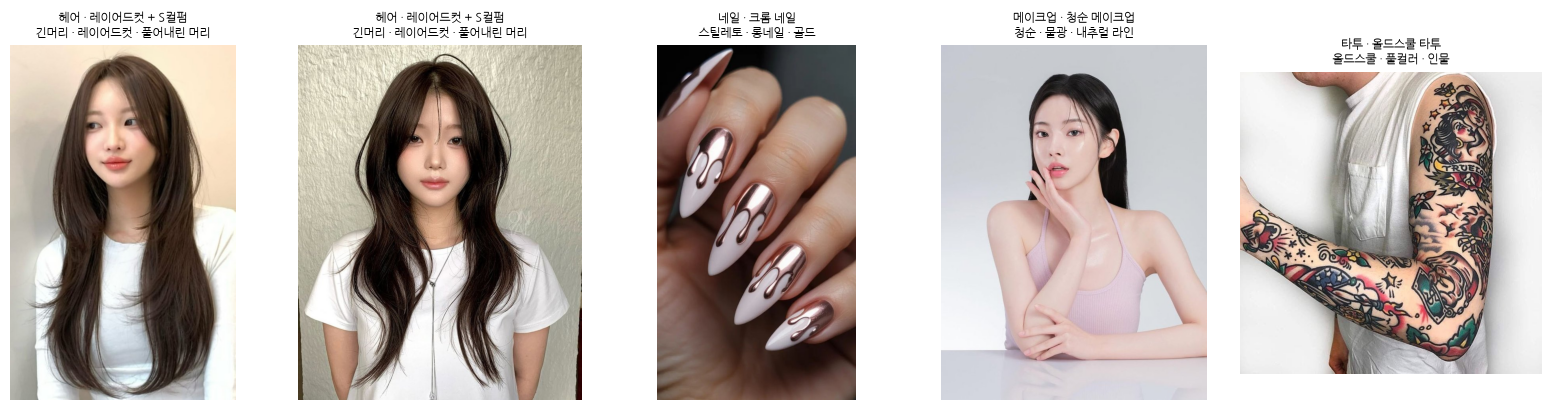


[samples/hair-01.jpg] 헤어 · 레이어드컷 + S컬펌  (뷰티 사진 91%, 0.27초)
  카테고리 순위: 헤어 98%, 메이크업 2%, 네일 0%, 타투 0%
  설명: 기장은 긴머리예요. 커트는 레이어드컷으로 보여요. 연출은 풀어내린 머리예요. 펌·질감은 S컬펌으로 보여요. 앞머리는 커튼뱅이에요. 컬러는 초코브라운으로 보여요. 컬러 기법은 전체 염색으로 보여요. 분위기는 청순으로 보여요.
  해시태그: #긴머리 #레이어드컷 #풀어내린머리 #S컬펌 #커튼뱅 #초코브라운 #전체염색 #청순

[samples/hair-23.jpg] 헤어 · 레이어드컷 + S컬펌  (뷰티 사진 95%, 0.16초)
  카테고리 순위: 헤어 96%, 메이크업 4%, 타투 0%, 네일 0%
  설명: 기장은 긴머리예요. 커트는 레이어드컷으로 보여요. 연출은 풀어내린 머리로 보여요. 펌·질감은 S컬펌으로 보여요. 앞머리는 커튼뱅이에요. 컬러는 초코브라운으로 보여요. 컬러 기법은 전체 염색으로 보여요. 분위기는 청순으로 보여요.
  해시태그: #긴머리 #레이어드컷 #풀어내린머리 #S컬펌 #커튼뱅 #초코브라운 #전체염색 #청순

[samples/nail-01.jpg] 네일 · 크롬 네일  (뷰티 사진 98%, 0.17초)
  카테고리 순위: 네일 95%, 메이크업 4%, 타투 1%, 헤어 1%
  설명: 쉐입은 스틸레토로 보여요. 길이는 롱네일이에요. 컬러는 골드로 보여요. 디자인은 크롬이에요. 구성은 동일디자인이에요. 마감은 메탈릭이에요. 분위기는 쇠맛이에요. 부위는 핸드예요.
  해시태그: #스틸레토 #롱네일 #골드 #크롬 #동일디자인 #메탈릭 #쇠맛 #핸드

[samples/makeup-01.jpg] 메이크업 · 청순 메이크업  (뷰티 사진 89%, 0.19초)
  카테고리 순위: 메이크업 93%, 헤어 4%, 타투 1%, 네일 1%
  설명: 무드는 청순이에요. 피부 표현은 물광으로 보여요. 아이라인은 내추럴 라인으로 보여요. 속눈썹은 내추럴 속눈썹이에요. 눈썹은

In [6]:
SAMPLES = ["samples/hair-01.jpg", "samples/hair-23.jpg", "samples/nail-01.jpg", "samples/makeup-01.jpg", "samples/tattoo-01.jpg"]
WEB = json.load(open(fetch("notebook/web_reference.json"), encoding="utf-8"))["results"]

results = {}
fig, axes = plt.subplots(1, len(SAMPLES), figsize=(3.2 * len(SAMPLES), 4.2))
for ax, path in zip(axes, SAMPLES):
    img = Image.open(fetch(path))
    r = analyze(img)
    r["text"] = describe(r)
    results[path] = r
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{r['category_label']} · {r['text']['genre']}\n{r['text']['headline']}", fontsize=8.5)
plt.tight_layout(); plt.show()

for path, r in results.items():
    print(f"\n[{path}] {r['category_label']} · {r['text']['genre']}  (뷰티 사진 {r['beauty_score']:.0%}, {r['elapsed_s']:.2f}초)")
    print("  카테고리 순위:", ", ".join(f"{TAX['tax'][c]['label']} {p:.0%}" for c, p in r["category_ranking"]))
    print("  설명:", " ".join(r["text"]["sentences"]))
    print("  해시태그:", " ".join(r["text"]["tags"]))

In [7]:
# 속성별 판단 근거 (예: 첫 번째 사진) — 웹 앱의 '속성별 판단 근거' 막대와 같은 값
r = results[SAMPLES[0]]
pd.DataFrame([{"그룹": a["group_label"], "1위": a["label"], "확률": f"{a['score']:.0%}", "단계": a["level"],
               "다음 후보": ", ".join(f"{x['label']} {x['score']:.0%}" for x in a["alternatives"]), "용어 설명": a["def"]}
              for a in r["attributes"]])

,그룹,1위,확률,단계,다음 후보,용어 설명
0,기장,긴머리,99%,high,"중단발 1%, 단발 0%",머리끝이 어깨를 훌쩍 넘어 가슴이나 등까지 내려오는 기장이에요.
1,커트,레이어드컷,86%,mid,"히메컷 8%, 허쉬컷 4%","얼굴선을 따라 길고 부드러운 층을 낸 커트로, 허쉬컷보다 층이 차분해요."
2,연출,풀어내린 머리,95%,high,"반묶음 3%, 사과머리 1%",묶거나 올리지 않고 그대로 풀어 내린 머리예요.
3,펌·질감,S컬펌,77%,mid,"생머리 19%, C컬펌 3%",머리 전체에 S자 모양의 느슨하고 굵은 웨이브가 흐르는 펌이에요.
4,앞머리,커튼뱅,92%,high,"시스루뱅 5%, U뱅 2%",가운데에서 갈라 양옆으로 커튼처럼 내려 얼굴선을 감싸는 앞머리예요.
5,컬러,초코브라운,60%,mid,"밀크브라운 18%, 카키브라운 8%",검은색에 가까울 만큼 진한 초콜릿빛 갈색이에요.
6,컬러 기법,전체 염색,77%,mid,"하이라이트 9%, 발레아쥬 8%",뿌리부터 끝까지 한 가지 색으로 고르게 물들인 머리예요.
7,톤,쿨톤,36%,low,"뉴트럴 32%, 웜톤 32%",붉거나 노란 기 없이 회색·푸른빛·보랏빛이 도는 차가운 계열의 머리색이에요.
8,분위기,청순,70%,mid,"러블리 24%, 시크 3%",꾸밈이 적은 생머리나 부드러운 컬로 맑고 순한 인상을 주는 분위기예요.


In [8]:
# 웹 앱(Transformers.js, 8비트) 결과와 비교: 같은 사진에서 카테고리와 속성 1위가 같은지
rows, same_all, n_all = [], 0, 0
for path, r in results.items():
    w = WEB[path]
    web_top = {g: (lab, s) for g, lab, s in w["attributes"]}
    same = sum(web_top[a["group"]][0] == a["label"] for a in r["attributes"])
    same_all += same; n_all += len(r["attributes"])
    we = np.array(w["embedding"]); cos = float(r["embedding"] @ we / np.linalg.norm(we))
    rows.append({"사진": path, "카테고리 (파이썬 / 웹)": f"{r['category']} / {w['category']}", "속성 1위 일치": f"{same}/{len(r['attributes'])}",
                 "웹 앱 장르": w["genre"], "특징값 코사인 유사도 (파이썬 vs 웹)": round(cos, 4)})
print(f"속성 1위 일치율 {same_all}/{n_all} = {same_all / n_all:.0%}  (차이는 웹 앱의 8비트 양자화 · 이미지 리사이즈 구현 차이에서 온다)")
pd.DataFrame(rows)

속성 1위 일치율 40/42 = 95%  (차이는 웹 앱의 8비트 양자화 · 이미지 리사이즈 구현 차이에서 온다)


,사진,카테고리 (파이썬 / 웹),속성 1위 일치,웹 앱 장르,특징값 코사인 유사도 (파이썬 vs 웹)
0,samples/hair-01.jpg,hair / hair,8/9,레이어드컷 + S컬펌,0.9830
1,samples/hair-23.jpg,hair / hair,8/9,레이어드컷,0.9621
2,samples/nail-01.jpg,nail / nail,8/8,크롬 네일,0.9712
3,samples/makeup-01.jpg,makeup / makeup,11/11,청순 메이크업,0.9558
4,samples/tattoo-01.jpg,tattoo / tattoo,5/5,올드스쿨 타투,0.9672


## 7. 분류 헤드 학습 방법 (`tools/train-heads.py`)

제로샷만 쓰면 속성 정확도가 53%였고, 그룹마다 작은 분류기를 얹어 73~78%가 됐습니다.

- 가중치를 **라벨 문장 임베딩(제로샷 답)에서 출발**시킨다: `logits = t · (T + Δ) · v + b`
- `Δ` 에 L2 벌점을 줘서 제로샷에서 크게 벗어나지 않게 한다 → 사진이 적어도(그룹당 수십~수백 장) 안정적
- 정답이 여러 개일 수 있는 약한 라벨은 '후보 중 하나' 확률을 키우는 **partial-label 손실**
- 학습 데이터에 없는 라벨은 손실에서 빼서 제로샷 판단을 유지
- 벌점 λ 와 섞는 비율 α 는 **출처 단위 교차 검증**으로 고르고(같은 작가 · 앨범 사진은 같은 폴드), 마지막에 확률 보정 온도를 맞춘다

아래 `fit` 은 학습 스크립트의 함수를 그대로 옮긴 것입니다.
실제 학습에는 사진 2,197장의 특징값이 필요해서(사진은 라이선스 때문에 저장소에 없음), 여기서는 **동작을 확인하는 작은 예시**를 돌립니다:
라벨 문장 임베딩에 '텍스트와 사진의 차이'(그룹 공통 이동 + 라벨별 이동 + 잡음)를 더해 가짜 사진 특징값을 만들고, 제로샷과 학습 헤드의 정확도를 비교합니다.

In [9]:
SCALE = 100.0

def softmax_rows(z):
    z = z - z.max(-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(-1, keepdims=True)

def fit(V, S, T, lam, present, steps=150, lr=0.03, smooth=0.05, sw=None):
    """V: N×D 사진 특징값, S: N×C 정답 후보 마스크(0/1), T: C×D 라벨 문장 임베딩(출발점). Adam 으로 Δ, b, 온도 t 를 학습"""
    N, D = V.shape; C = T.shape[0]
    D_ = np.zeros_like(T); b = np.zeros(C); logt = np.log(SCALE)
    mask = np.full(C, -1e9); mask[present] = 0.0
    freq = S.sum(0) / max(S.sum(), 1)
    w = 1.0 / np.maximum((S * freq).sum(1) / np.maximum(S.sum(1), 1), 1e-3)   # 클래스 불균형 보정
    if sw is not None: w = w * sw
    w = w / w.mean()
    m = {k: 0.0 for k in ("D", "b", "t")}; v2 = {k: 0.0 for k in ("D", "b", "t")}
    for step in range(1, steps + 1):
        t = np.exp(logt)
        sims = V @ (T + D_).T
        p = softmax_rows(t * sims + b + mask)
        q = p * S; q = q / np.maximum(q.sum(1, keepdims=True), 1e-12)          # partial-label 목표
        q = (1 - smooth) * q + smooth * (p > 0) * (mask == 0) / max(len(present), 1)
        gz = (p - q) * w[:, None] / N
        gD = t * gz.T @ V + 2 * lam * D_
        gb = gz.sum(0)
        gt = (gz * sims).sum() * t
        for k, g in (("D", gD), ("b", gb), ("t", gt)):
            m[k] = 0.9 * m[k] + 0.1 * g; v2[k] = 0.999 * v2[k] + 0.001 * g * g
            upd = lr * (m[k] / (1 - 0.9 ** step)) / (np.sqrt(v2[k] / (1 - 0.999 ** step)) + 1e-8)
            if k == "D": D_ -= upd
            elif k == "b": b -= upd
            else: logt -= upd
    b[[i for i in range(C) if i not in set(present)]] = b[present].mean() if len(present) else 0.0
    return np.exp(logt) * (T + D_), b

def predict(V, W, b, T, alpha):
    return alpha * softmax_rows(V @ W.T + b) + (1 - alpha) * softmax_rows(SCALE * V @ T.T)

# 동작 확인용 예시: 헤어 '커트' 그룹 (라벨 24개)
# 실제 사진에서 생기는 문제를 흉내 낸다: 라벨 절반은 사진이 '다른 라벨의 문장'에 더 가깝게 찍힌다
# (예: 허쉬컷 사진이 레이어드컷 문장과 더 비슷함) → 제로샷은 틀리고, 학습 헤드가 이 차이를 배운다
rng = np.random.default_rng(0)
T = INDEX["hair"]["groups"]["cut"].astype(np.float64)
C, D = T.shape
unit = lambda X: X / np.linalg.norm(X, axis=-1, keepdims=True)
confused_with = rng.permutation(C)
confusing = np.arange(C) % 2 == 0
def fake_photos(n_per):
    y = np.repeat(np.arange(C), n_per)
    base = np.where(confusing[y][:, None], 0.4 * T[y] + 0.6 * T[confused_with[y]], T[y])
    return unit(base + rng.normal(scale=0.03, size=(len(y), D))), y
Xtr, ytr = fake_photos(12)      # 라벨당 12장으로 학습
Xte, yte = fake_photos(20)      # 새 사진 20장씩으로 평가
S = np.eye(C)[ytr]
zs_acc = (softmax_rows(SCALE * Xte @ T.T).argmax(1) == yte).mean()
print(f"제로샷 정확도: {zs_acc:.1%}")
for lam in (1.0, 10.0):
    W, b = fit(Xtr, S, T, lam, list(range(C)))
    for alpha in (0.5, 1.0):
        acc = (predict(Xte, W, b, T, alpha).argmax(1) == yte).mean()
        print(f"  λ={lam:>4}, α={alpha}: 학습 헤드 정확도 {acc:.1%}")
print("→ 벌점 λ 가 크면 제로샷에 가깝게 남고, 작으면 데이터에 더 맞춘다. 실제 학습에서는 교차 검증으로 그룹마다 고른다.")

제로샷 정확도: 50.8%


  λ= 1.0, α=0.5: 학습 헤드 정확도 54.4%
  λ= 1.0, α=1.0: 학습 헤드 정확도 81.5%


  λ=10.0, α=0.5: 학습 헤드 정확도 52.9%
  λ=10.0, α=1.0: 학습 헤드 정확도 70.2%
→ 벌점 λ 가 크면 제로샷에 가깝게 남고, 작으면 데이터에 더 맞춘다. 실제 학습에서는 교차 검증으로 그룹마다 고른다.


**실제 데이터의 결과** (학습에 쓰지 않은 사진, `docs/MODEL_CARD.md`)

| 측정 | 제로샷 | 기본 모델 + 학습 헤드 | 정밀 모델 + 학습 헤드 |
|---|---|---|---|
| 속성 정확도 (교차 검증, 2,257개) | 53.0% | 73.4% | **75.4%** |
| 평가 세트 속성 정확도 (812개) | 58.0% | 75.1% | **78.0%** |
| 한국 스타일 사진 (교차 검증, 718개) | 53.2% | 72.3% | **74.5%** |
| "~예요"로 단정한 문장의 적중률 | – | 96.3% | **96.9%** |

가장 크게 배운 점은 **라벨의 질이 양보다 중요하다**는 것입니다. 검색어로 자동 라벨을 단 1만 장은 효과가 없었고(73.9% → 73.4%),
사진을 직접 보고 단 280장은 +5.9%p 를 올렸습니다. 한국 스타일 사진 98장은 한국 사진 정확도를 67.0% → 76.7% 로 올렸습니다.

## 8. 내 얼굴 분석 — 얼굴형 측정 (`face.js` 를 파이썬으로)

셀카 한 장으로 얼굴형을 재고 헤어 · 메이크업을 맞춤 추천하는 기능입니다. MediaPipe 두 가지를 씁니다.

- **얼굴 랜드마크 478점** (`face_landmarker.task`): 눈 · 코 · 입 · 눈썹 위치, 고개 각도
- **부위 분할** (`selfie_multiclass_256x256.tflite`, Apache-2.0): 픽셀마다 배경 · 머리카락 · 몸 피부 · **얼굴 피부** · 옷 · 기타

순서
1. 양쪽 광대 방향을 가로축, 턱끝 → 이마를 세로축으로 하는 **얼굴 좌표계**로 옮겨 고개 기울기를 보정
2. 랜드마크 윤곽은 평균 얼굴 쪽으로 끌리는 경향이 있어, **턱선 · 턱끝 · 헤어라인은 분할 마스크의 실제 얼굴 피부 가장자리**를 쓴다
3. 이마 · 광대 · 턱 · 턱끝 너비, 얼굴 길이, 삼정, 턱 모서리 각도를 재고
4. **앞머리 · 옆머리 · 손이 얼굴선을 가리면 재지 않고 다시 찍어 달라고** 한다
5. 6가지 얼굴형(계란 · 둥근 · 긴 · 각진 · 하트 · 마름모)과의 거리로 **확률**을 낸다

In [10]:
import contextlib
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

@contextlib.contextmanager
def quiet_stderr():
    """MediaPipe(C++)가 표준 오류로 내보내는 시작 안내 메시지를 가린다"""
    fd = os.dup(2); null = os.open(os.devnull, os.O_WRONLY)
    os.dup2(null, 2)
    try: yield
    finally: os.dup2(fd, 2); os.close(fd); os.close(null)

with quiet_stderr():
  face_landmarker = mp_vision.FaceLandmarker.create_from_options(mp_vision.FaceLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=fetch("models/mediapipe/face_landmarker.task")),
    num_faces=3, output_face_blendshapes=True, output_facial_transformation_matrixes=True))
  segmenter = mp_vision.ImageSegmenter.create_from_options(mp_vision.ImageSegmenterOptions(
    base_options=mp_python.BaseOptions(model_asset_path=fetch("models/mediapipe/selfie_multiclass_256x256.tflite")),
    output_category_mask=True))
SEG = {"bg": 0, "hair": 1, "body": 2, "face": 3, "clothes": 4, "other": 5}

# 랜드마크 번호 (MediaPipe Face Mesh)
OVAL = [10, 338, 297, 332, 284, 251, 389, 356, 454, 323, 361, 288, 397, 365, 379, 378, 400, 377, 152, 148, 176, 149, 150, 136, 172, 58, 132, 93, 234, 127, 162, 21, 54, 103, 67, 109]
BROW_ALL = [70, 63, 105, 66, 107, 55, 65, 52, 53, 46, 300, 293, 334, 296, 336, 285, 295, 282, 283, 276]
BROW_TOP = [70, 63, 105, 66, 107, 336, 296, 334, 293, 300]
SIDE_ZONES = [("관자놀이", "temple", [21, 162], [251, 389]), ("볼 옆선", "cheek", [127, 234, 93], [356, 454, 323]),
              ("턱선", "jaw", [132, 58, 172, 136, 150], [361, 288, 397, 365, 379])]

def detect_face(img: Image.Image):
    rgb = np.ascontiguousarray(np.array(img.convert("RGB")))
    mimg = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    with quiet_stderr():
        res = face_landmarker.detect(mimg)
        seg_res = segmenter.segment(mimg)
    seg = np.squeeze(seg_res.category_mask.numpy_view()).copy()   # (높이, 너비) 부위 번호
    if not res.face_landmarks:
        return None
    sizes = [np.ptp([p.x for p in lm]) * np.ptp([p.y for p in lm]) for lm in res.face_landmarks]
    i = int(np.argmax(sizes))
    lm = np.array([[p.x, p.y, p.z] for p in res.face_landmarks[i]])
    blend = {c.category_name: c.score for c in res.face_blendshapes[i]} if res.face_blendshapes else {}
    mat = np.array(res.facial_transformation_matrixes[i]) if res.facial_transformation_matrixes else None
    return {"lm": lm, "blend": blend, "mat": mat, "seg": seg, "w": rgb.shape[1], "h": rgb.shape[0], "rgb": rgb}

In [11]:
def measure_face(d):
    """face.js 의 measureFace 를 옮긴 것. 반환: 측정값 m, 고개 각도, 가림 비율, 그리기용 좌표"""
    w, h, seg = d["w"], d["h"], d["seg"]
    sh, sw = seg.shape
    P3 = d["lm"] * np.array([w, h, w])                       # z 는 x 와 같은 척도
    X = P3[454] - P3[234]; X /= np.linalg.norm(X)            # 가로축: 왼쪽 광대 → 오른쪽 광대
    up = P3[10] - P3[152]; Y = up - X * (up @ X); Y /= np.linalg.norm(Y)   # 세로축: 턱끝 → 이마 위
    Z = np.cross(X, Y); O = (P3[234] + P3[454]) / 2
    U = lambda i: np.array([(P3[i] - O) @ X, (P3[i] - O) @ Y])
    V = lambda i: U(i)[1]
    to_img = lambda u, v, z=0.0: (O + X * u + Y * v + Z * z)[:2]
    def seg_uv(u, v, z=0.0):
        x, y = to_img(u, v, z)
        ix, iy = int(x / w * sw), int(y / h * sh)
        return -1 if ix < 0 or iy < 0 or ix >= sw or iy >= sh else int(seg[iy, ix])
    # 고개 각도 (변환 행렬의 회전 부분)
    R = d["mat"][:3, :3] if d["mat"] is not None else np.eye(3)
    pose = {"yaw": math.degrees(math.atan2(-R[2, 0], math.hypot(R[0, 0], R[1, 0]))),
            "pitch": math.degrees(math.atan2(R[2, 1], R[2, 2])), "roll": math.degrees(math.atan2(R[1, 0], R[0, 0]))}

    oval = np.array([U(i) for i in OVAL])
    vTop, vSub = V(10), V(2)
    vStom, vMouth = (V(13) + V(14)) / 2, (V(61) + V(291)) / 2
    vEye, vNose = np.mean([V(i) for i in (33, 133, 362, 263)]), V(1)
    vBrow, vBrowTop = np.mean([V(i) for i in BROW_ALL]), np.mean([V(i) for i in BROW_TOP])
    zTop = (P3[10] - O) @ Z

    def slice_(v):  # 높이 v 에서 메시 윤곽과 만나는 왼쪽 · 오른쪽 가로 위치
        xs = []
        for (ua, va), (ub, vb) in zip(oval, np.roll(oval, -1, axis=0)):
            if (va - v) * (vb - v) <= 0 and va != vb:
                xs.append(ua + (v - va) / (vb - va) * (ub - ua))
        return (min(xs), max(xs)) if len(xs) >= 2 else None
    # 광대: 눈높이 위 ~ 코끝 사이에서 메시 윤곽이 가장 넓은 곳
    cheek = max(((v, *slice_(v)) for v in np.linspace(vEye + (vEye - vNose) * 0.25, vNose, 25) if slice_(v)), key=lambda s: s[2] - s[1])
    cv, cl, cr = cheek
    CW = cr - cl

    def edge(v, side, z=0.0):  # 메시 윤곽 근처에서 바깥으로 걸으며 얼굴 피부가 끝나는 곳
        s = slice_(v)
        if not s: return None
        um = s[0] if side < 0 else s[1]
        last, miss = None, 0
        for k in range(91):
            u = um + side * CW * (-0.2 + 0.4 * k / 90)
            if seg_uv(u, v, z) == SEG["face"]: last, miss = u, 0
            elif last is not None:
                miss += 1
                if miss >= 3: break
        return None if last is None else (last, side * (last - um) / CW, um)
    def pick(e, um, lo, hi):
        return e[0] if e and lo < e[1] < hi else um

    # 턱끝: 입 가운데에서 아래로 내려가며 얼굴 피부가 끝나는 곳
    vMenton = V(152)
    last, miss = None, 0
    for v in np.linspace(vStom, vMenton - CW * 0.25, 81):
        if sum(seg_uv(j * CW * 0.03, v) == SEG["face"] for j in (-1, 0, 1)) >= 2: last, miss = v, 0
        elif last is not None:
            miss += 1
            if miss >= 3: break
    if last is not None and abs(last - vMenton) < CW * 0.08: vMenton = last

    # 턱선: 광대 높이 → 턱끝, 좌우 가장자리 (마스크 우선, 크게 벗어나면 메시)
    K = 30
    jawL, jawR = [], []
    for k in range(K + 1):
        v = cv + (vMenton - cv) * k / K
        s = slice_(v)
        if not s: continue
        for side, pts in ((-1, jawL), (1, jawR)):
            um = s[0] if side < 0 else s[1]
            u = (cl if side < 0 else cr) if k == 0 else 0.0 if k == K else pick(edge(v, side), um, -0.08, 0.05)
            pts.append((u, v))
    def at(pts, v, side):
        for (ua, va), (ub, vb) in zip(pts, pts[1:]):
            if (va - v) * (vb - v) <= 0 and va != vb:
                return ua + (v - va) / (vb - va) * (ub - ua)
        s = slice_(v)
        return (s[0] if side < 0 else s[1]) if s else 0.0
    vChin = vMenton + (vStom - vMenton) * 0.3
    jawW = at(jawR, vMouth, 1) - at(jawL, vMouth, -1)
    chinW = at(jawR, vChin, 1) - at(jawL, vChin, -1)
    def angle_at(g, a, b):
        p, q = np.subtract(a, g), np.subtract(b, g)
        return math.degrees(math.acos(np.clip(p @ q / (np.linalg.norm(p) * np.linalg.norm(q)), -1, 1)))
    M = (0.0, vMenton)
    def gonial(pts):  # 광대 점 → 턱끝 직선에서 가장 바깥으로 나온 턱선 점 = 턱 모서리
        C = np.array(pts[0]); best, bd = None, -1
        for p in pts:
            if p[1] > cv - CW * 0.08 or p[1] < vMenton + CW * 0.05: continue
            dist = abs((M[0] - C[0]) * (C[1] - p[1]) - (C[0] - p[0]) * (M[1] - C[1])) / math.hypot(M[0] - C[0], M[1] - C[1])
            if dist > bd: bd, best = dist, p
        return angle_at(best, C, M), bd / CW, best
    gA, gB = gonial(jawL), gonial(jawR)

    # 이마 너비 (눈썹 위 ~ 이마 위 40% 높이)
    vFore = vBrowTop + (vTop - vBrowTop) * 0.4
    fs = slice_(vFore)
    fl, fr = pick(edge(vFore, -1, zTop * 0.5), fs[0], -0.08, 0.04), pick(edge(vFore, 1, zTop * 0.5), fs[1], -0.08, 0.04)

    # 헤어라인: 이마 가운데를 따라 올라가며 얼굴 피부가 끝나는 곳 (가르마 사이 두피를 피하려고 폭도 본다)
    hairline, last, miss = None, None, 0
    for k, v in enumerate(np.linspace(vBrowTop + (vTop - vBrowTop) * 0.3, vTop + CW * 0.75, 91)):
        face = sum(seg_uv(j / 2 * CW * 0.08, v, zTop) == SEG["face"] for j in range(-2, 3))
        wide = sum(seg_uv(j / 4 * CW * 0.16, v, zTop) == SEG["face"] for j in range(-4, 5))
        if face >= 3 and (wide >= 5 or last is None): last, miss = v, 0
        elif last is not None:
            miss += 1
            if miss >= 3: break
        elif k > 3: break
    if last is not None and miss >= 3: hairline = last
    vHair = max(hairline, vBrowTop + CW * 0.12) if hairline is not None else vTop + (vTop - vBrow) * 0.42
    thirds = np.array([vHair - vBrow, vBrow - vSub, vSub - vMenton]); thirds = thirds / thirds.sum() * 3

    mouthW = abs(U(291)[0] - U(61)[0])
    m = {"ratio": (vHair - vMenton) / CW, "forehead": (fr - fl) / CW, "jaw": jawW / CW, "chin": chinW / CW,
         "jawAngle": (gA[0] + gB[0]) / 2, "jawBulge": (gA[1] + gB[1]) / 2, "thirds": thirds,
         "lipGap": (V(13) - V(14)) / mouthW, "cornerLift": ((V(61) + V(291)) / 2 - vStom) / mouthW}

    # 가림 점검: 이마 안쪽 · 얼굴선 안쪽 띠에서 머리카락 · 손(몸 피부) 픽셀 비율
    def frac(pts, cls):
        vals = [seg_uv(*p) for p in pts]
        return sum(v == SEG[cls] for v in vals) / max(1, len(vals))
    fpts = [((b / 3) * CW * 0.27, vBrowTop + (vTop - vBrowTop) * (0.12 + 0.14 * a), zTop * 0.5) for a in range(5) for b in range(-3, 4)]
    cover = {"forehead_hair": frac(fpts, "hair")}
    for label, key, ids_a, ids_b in SIDE_ZONES:
        for side, ids in (("a", ids_a), ("b", ids_b)):
            pts = []
            for i in ids:
                u, v = U(i); s = 1 if u >= 0 else -1
                pts += [(u - s * dd * CW, v, 0.0) for dd in (0.03, 0.06, 0.09)]
            cover[f"{key}_{side}_hair"] = frac(pts, "hair"); cover[f"{key}_{side}_body"] = frac(pts, "body")

    P = lambda u, v, z=0.0: to_img(u, v, z)
    geo = {"oval": np.array([P3[i][:2] for i in OVAL]),
           "jaw": np.array([P(u, v) for u, v in jawL] + [P(u, v) for u, v in reversed(jawR)]),
           "widths": {"이마": (P(fl, vFore, zTop * 0.5), P(fr, vFore, zTop * 0.5)), "광대": (P(cl, cv), P(cr, cv)),
                      "턱": (P(at(jawL, vMouth, -1), vMouth), P(at(jawR, vMouth, 1), vMouth)), "턱끝": (P(at(jawL, vChin, -1), vChin), P(at(jawR, vChin, 1), vChin))},
           "thirds": [(P(-CW * 0.55, v, zTop if i == 0 else 0), P(CW * 0.55, v, zTop if i == 0 else 0)) for i, v in enumerate((vHair, vBrow, vSub, vMenton))],
           "gonion": (P(*gA[2]), P(*gB[2]))}
    return {"m": m, "pose": pose, "cover": cover, "geo": geo, "hairline_found": hairline is not None, "CW": CW}

In [12]:
# 다시 찍어 주세요 점검 (face.js 의 checkIssues 중 핵심)
def check_issues(f, d):
    m, pose, cov, out = f["m"], f["pose"], f["cover"], []
    if abs(pose["yaw"]) > 12: out.append(("block", f"고개가 옆으로 {abs(pose['yaw']):.0f}° 돌아갔어요 — 카메라를 정면으로"))
    if abs(pose["pitch"]) > 20: out.append(("block", f"고개를 {abs(pose['pitch']):.0f}° 들거나 숙였어요 — 카메라를 눈높이에"))
    if d["blend"].get("jawOpen", 0) > 0.25 or m["lipGap"] > 0.15: out.append(("block", "입이 벌어져 있어요 — 입을 다물고"))
    smile = max((d["blend"].get("mouthSmileLeft", 0) + d["blend"].get("mouthSmileRight", 0)) / 2, 0.35 + (m["cornerLift"] - 0.05) * 4 if m["cornerLift"] > 0.05 else 0)
    if smile > 0.5: out.append(("block", "활짝 웃고 있어요 — 무표정으로"))
    if cov["forehead_hair"] > 0.2: out.append(("block", f"앞머리가 이마를 {cov['forehead_hair']:.0%} 가리고 있어요 — 앞머리를 넘겨 이마와 헤어라인이 보이게"))
    sides = [(label, s) for label, key, _, _ in SIDE_ZONES if key != "temple" for s in "ab" if cov[f"{key}_{s}_hair"] > 0.25]
    if sides: out.append(("block", f"옆머리가 {' · '.join(sorted({l for l, _ in sides}))}을 가리고 있어요 — 귀 뒤로 넘기거나 묶어서"))
    if any(cov[f"{key}_{s}_body"] > (0.55 if key == "jaw" else 0.2) for _, key, _, _ in SIDE_ZONES for s in "ab"):
        out.append(("block", "손이 얼굴선을 가리고 있어요 — 손을 얼굴에서 떼고"))
    if not f["hairline_found"] and not any("앞머리" in t for _, t in out): out.append(("warn", "헤어라인을 찾지 못해 이마 높이는 평균 비율로 어림했어요"))
    return out

# 얼굴형 확률: 측정값의 표준점수와 얼굴형별 특징 방향 사이의 거리 → softmax (face.js 의 classifyShape)
NORM = {"ratio": (1.36, 0.09), "forehead": (0.81, 0.045), "jaw": (0.84, 0.05), "chin": (0.45, 0.055), "jawAngle": (130.5, 5), "jawBulge": (0.203, 0.016)}
SHAPES = {"oval": "계란형", "round": "둥근형", "long": "긴 얼굴형", "square": "각진형", "heart": "하트형(역삼각형)", "diamond": "마름모형(다이아몬드)"}
PROTO = {  # 얼굴형마다 특징 방향 (표준편차 단위, + 크다 / - 작다)
    "oval":    {"ratio": 0.3, "forehead": 0, "jaw": -0.2, "chin": -0.2, "jawAngle": 0.2, "jawBulge": -0.2},
    "round":   {"ratio": -1.4, "forehead": 0, "jaw": 0.6, "chin": 0.8, "jawAngle": 0.7, "jawBulge": 0.6},
    "long":    {"ratio": 1.6, "forehead": 0, "jaw": 0, "chin": 0, "jawAngle": 0, "jawBulge": -0.3},
    "square":  {"ratio": -0.6, "forehead": 0.5, "jaw": 1.3, "chin": 0.9, "jawAngle": -1.3, "jawBulge": 1.2},
    "heart":   {"ratio": 0.2, "forehead": 1.3, "jaw": -1.2, "chin": -1.1, "jawAngle": 0.7, "jawBulge": -1.0},
    "diamond": {"ratio": 0.3, "forehead": -1.4, "jaw": -1.0, "chin": -0.8, "jawAngle": 0.5, "jawBulge": -0.6},
}
WEIGHT = {"ratio": 1.4, "forehead": 1, "jaw": 1.1, "chin": 0.8, "jawAngle": 0.8, "jawBulge": 0.8}
def classify_shape(m, T=3.0):
    z = {k: (m[k] - NORM[k][0]) / NORM[k][1] for k in NORM}
    dist = {s: sum(WEIGHT[k] * (z[k] - p[k]) ** 2 for k in WEIGHT) for s, p in PROTO.items()}
    e = {s: math.exp(-v / T) for s, v in dist.items()}
    tot = sum(e.values())
    return sorted(((SHAPES[s], e[s] / tot) for s in e), key=lambda x: -x[1]), z

from matplotlib.path import Path as MplPath
def occlusion_overlay(d, f):
    """얼굴선 안쪽에서 머리카락 · 손 · 소품으로 분할된 픽셀을 붉게 (웹 앱의 '다시 찍어 주세요' 그림)"""
    h, w = d["h"], d["w"]; seg = d["seg"]; sh, sw = seg.shape
    yy, xx = np.mgrid[0:h:2, 0:w:2]
    inside = MplPath(f["geo"]["oval"]).contains_points(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    cls = seg[yy * sh // h, xx * sw // w]
    rgba = np.zeros(xx.shape + (4,))
    rgba[inside & np.isin(cls, [SEG["hair"], SEG["body"], SEG["other"]])] = [0.92, 0.1, 0.1, 0.55]
    return rgba

def draw_face(d, f, ax, title, blocked=False):
    ax.imshow(d["rgb"]); ax.axis("off"); ax.set_title(title, fontsize=10)
    g = f["geo"]
    if blocked:   # 재지 않는 사진은 가린 곳만 보여 준다
        ax.imshow(occlusion_overlay(d, f), extent=(0, d["w"], d["h"], 0))
        ax.plot(*np.vstack([g["oval"], g["oval"][:1]]).T, "--", color="white", lw=1)
        xs, ys = g["oval"][:, 0], g["oval"][:, 1]; pad = np.ptp(xs) * 0.45
        ax.set_xlim(xs.min() - pad, xs.max() + pad); ax.set_ylim(ys.max() + pad * 0.6, ys.min() - pad * 0.9)
        return
    ax.plot(*np.vstack([g["oval"], g["oval"][:1]]).T, "--", color="white", lw=0.8, alpha=0.7)
    ax.plot(*g["jaw"].T, "-", color="white", lw=1.6)
    colors = {"이마": "#9fd0ff", "광대": "#ffe08a", "턱": "#ff9f8f", "턱끝": "#ffc27a"}
    vals = {"이마": f["m"]["forehead"], "광대": 1.0, "턱": f["m"]["jaw"], "턱끝": f["m"]["chin"]}
    for name, (a, b) in g["widths"].items():
        ax.plot([a[0], b[0]], [a[1], b[1]], color=colors[name], lw=2)
        ax.text(b[0] + 6, b[1], f"{name} {vals[name]:.2f}", color=colors[name], fontsize=8, va="center",
                bbox=dict(facecolor="black", alpha=0.55, pad=1.5, lw=0))
    for a, b in g["thirds"]:
        ax.plot([a[0], b[0]], [a[1], b[1]], ":", color="#c8f0b0", lw=1.2)
    for p in g["gonion"]:
        ax.plot(*p, "o", color="#ff7ad9", ms=5)
    xs, ys = g["oval"][:, 0], np.r_[g["oval"][:, 1], g["thirds"][0][0][1]]
    pad = np.ptp(xs) * 0.45
    ax.set_xlim(xs.min() - pad, xs.max() + pad); ax.set_ylim(ys.max() + pad * 0.6, ys.min() - pad * 0.6)


[samples/makeup-14.jpg] 고개 각도 yaw -1° · pitch 6° · roll -16°
  얼굴 길이 : 광대 너비 = 1.45 : 1 (평균 1.36)
  이마 : 광대 : 턱 너비 = 0.81 : 1 : 0.84   턱끝 너비 0.34
  턱 모서리 각도 135° (평균 130.5°)   삼정 0.88 : 1.07 : 1.04
  얼굴형: 계란형 30%, 하트형(역삼각형) 24%, 긴 얼굴형 23%, 마름모형(다이아몬드) 21%, 둥근형 1%, 각진형 0%



[samples/hair-01.jpg] 고개 각도 yaw -9° · pitch 7° · roll 5°
  → 다시 찍어 주세요:
    - 앞머리가 이마를 29% 가리고 있어요 — 앞머리를 넘겨 이마와 헤어라인이 보이게
    - 옆머리가 볼 옆선을 가리고 있어요 — 귀 뒤로 넘기거나 묶어서


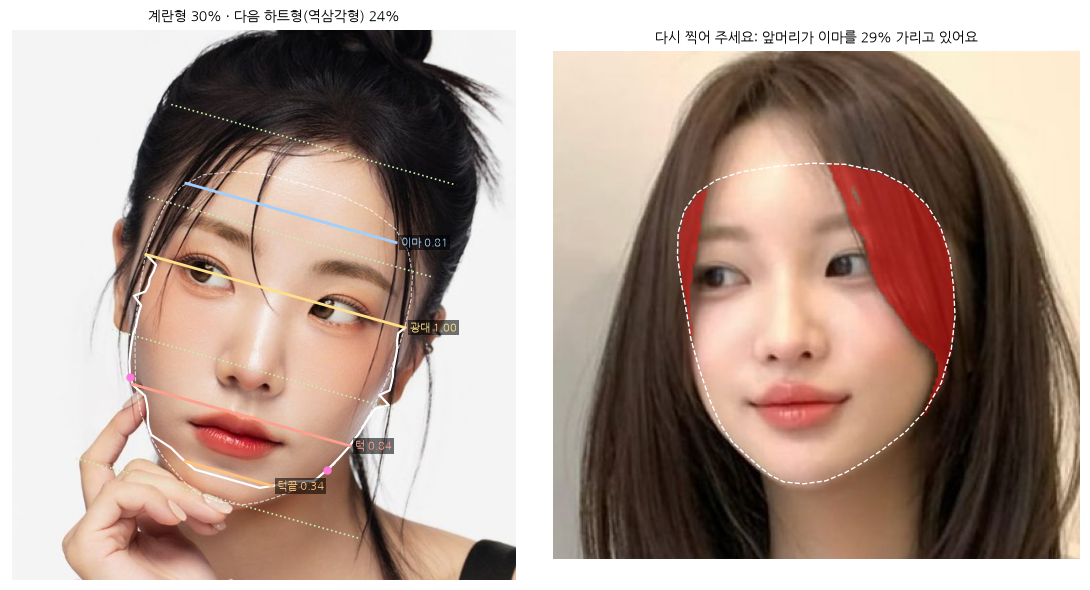

In [13]:
# 예시 사진 두 장: 머리를 묶어 얼굴선이 보이는 사진 / 앞머리 · 옆머리가 얼굴선을 가린 사진
FACE_SAMPLES = ["samples/makeup-14.jpg", "samples/hair-01.jpg"]
fig, axes = plt.subplots(1, 2, figsize=(11, 6.5))
for ax, path in zip(axes, FACE_SAMPLES):
    d = detect_face(Image.open(fetch(path)))
    f = measure_face(d)
    issues = check_issues(f, d)
    blocked = [t for lv, t in issues if lv == "block"]
    probs, z = classify_shape(f["m"])
    print(f"\n[{path}] 고개 각도 yaw {f['pose']['yaw']:.0f}° · pitch {f['pose']['pitch']:.0f}° · roll {f['pose']['roll']:.0f}°")
    if blocked:
        print("  → 다시 찍어 주세요:")
        for t in blocked: print("    -", t)
        title = "다시 찍어 주세요: " + blocked[0].split(" — ")[0]
    else:
        m = f["m"]
        print(f"  얼굴 길이 : 광대 너비 = {m['ratio']:.2f} : 1 (평균 {NORM['ratio'][0]})")
        print(f"  이마 : 광대 : 턱 너비 = {m['forehead']:.2f} : 1 : {m['jaw']:.2f}   턱끝 너비 {m['chin']:.2f}")
        print(f"  턱 모서리 각도 {m['jawAngle']:.0f}° (평균 {NORM['jawAngle'][0]}°)   삼정 {' : '.join(f'{x:.2f}' for x in m['thirds'])}")
        print("  얼굴형:", ", ".join(f"{name} {p:.0%}" for name, p in probs))
        for lv, t in issues: print("  (참고)", t)
        title = f"{probs[0][0]} {probs[0][1]:.0%} · 다음 {probs[1][0]} {probs[1][1]:.0%}"
    draw_face(d, f, ax, title, blocked=bool(blocked))
plt.tight_layout(); plt.show()

웹 앱에서는 여기에 더해
- 가린 부분을 사진 위에 **붉게 칠해서** 무엇을 고칠지 보여 주고,
- 측정값을 평균과 비교한 특징(예: "중안부가 긴 편")과 얼굴형으로 **헤어 추천**(커트 · 앞머리 · 기장 · 가르마 · 피할 스타일)과
  **메이크업 추천**(쉐딩 · 하이라이터 · 블러셔 위치를 얼굴 위에 그림, 눈썹 · 아이라인 · 입술)을 보여 주며,
- 직전에 분석한 스타일과 **내 얼굴의 궁합**을 알려 줍니다 (`face-advice.js`).

## 정리

| 항목 | 내용 |
|---|---|
| 입력 | 헤어 · 네일 · 메이크업 · 타투 사진 1장 / 내 셀카 |
| 출력 | 장르 · 트렌드 키워드 · 한국어 설명 · 해시태그 · 시술 요청서 · 사진 속 색 · 이런 분께 잘 어울려요 · 비슷한 스타일 / 얼굴형 · 측정값 · 맞춤 추천 |
| 모델 | Marqo FashionSigLIP (Transformers.js) + 직접 학습한 분류 헤드 34개 + 확률 보정, MediaPipe 얼굴 랜드마크 · 부위 분할 |
| 결과 | 속성 정확도 제로샷 53% → 73~78%, 단정 문장 적중률 96% |
| 실행 | 브라우저 안에서만 (사진을 서버로 보내지 않음), 사진 1장 분석 약 0.6초 (CPU) |